In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chi2, genpareto
from statsmodels.stats.multitest import multipletests

In [3]:
THRESH = 1e-2

In [4]:
all_epidemics_ds = pd.read_excel("../../data/raw/epidemics_marani_240816.xlsx")
all_epidemics_ds = all_epidemics_ds.rename(columns={'severity_smu': 'severity'}) # Name change simplifies code later

In [5]:
all_epidemics_ds['intensity'] = all_epidemics_ds['severity'] / all_epidemics_ds['duration']

In [6]:
above_threshold_epidemics = all_epidemics_ds[all_epidemics_ds['intensity'] >= THRESH]
above_threshold_epidemics = above_threshold_epidemics[above_threshold_epidemics['year_start'] >= 1600]

In [7]:
marani_params = {
  'shape': 1.40,
	'loc': 0.01,
  'scale':0.0113
}

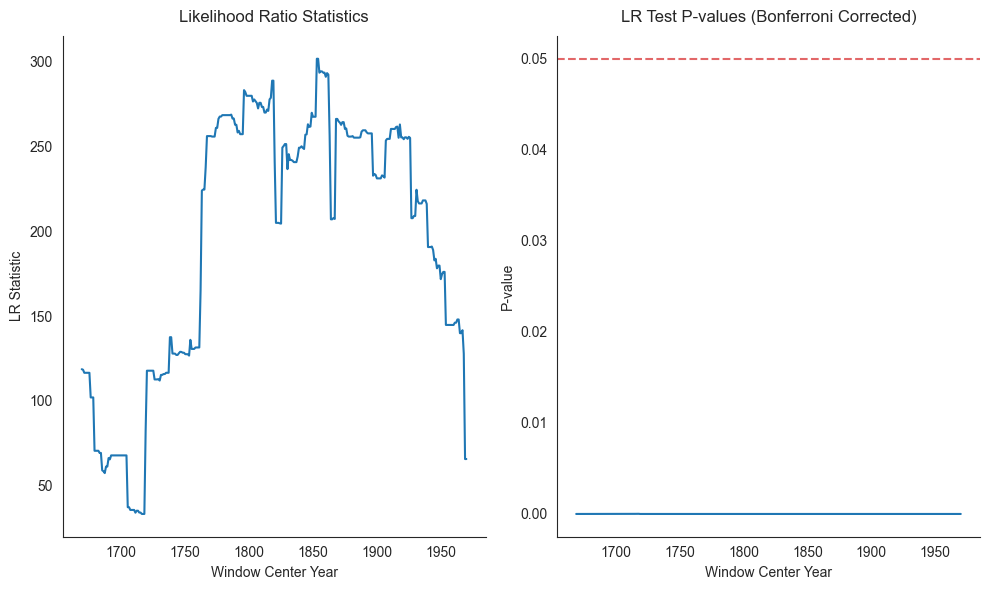

In [8]:
# Stationarity Tests

def fit_gpd(data):
    """
    Fit a GPD to data and return parameters and log likelihood
    
    Args:
        data (array-like): Data to fit GPD to
        
    Returns:
        tuple: (shape, loc, scale, log_likelihood)
    """
    shape, loc, scale = genpareto.fit(data)
    log_lik = np.sum(genpareto.logpdf(data, shape, loc, scale))
    return shape, loc, scale, log_lik

def rolling_window_test(data_df, window_size=10):
    """
    Perform rolling window GPD fits and likelihood ratio tests
    
    Args:
        data_df (pd.DataFrame): DataFrame containing 'intensity' and 'year_start' columns
        window_size (int): Size of rolling window
        
    Returns:
        tuple: (times, lr_stats, p_values)
    """
    # Fit full dataset
    full_shape, full_loc, full_scale, _ = fit_gpd(data_df['intensity'].values)
    
    half_window = window_size // 2
    min_year = data_df['year_start'].min() + half_window + 1
    max_year = data_df['year_start'].max() - half_window + 1
    
    times = []
    lr_stats = []
    p_values = []
    
    for center_year in range(min_year, max_year + 1):
        # Get data points within window centered on year
        window_df = data_df[
            (data_df['year_start'] >= center_year - half_window) & 
            (data_df['year_start'] <= center_year + half_window)
        ]
        
        _, _, _, window_ll = fit_gpd(window_df['intensity'].values)
        full_in_window_ll = np.sum(genpareto.logpdf(window_df['intensity'].values, full_scale, loc=full_loc, scale=full_scale))
        
        lr = -2 * (full_in_window_ll - window_ll)
        p_val = 1 - chi2.cdf(lr, df=2)  # 2 degrees of freedom
        
        times.append(center_year)
        lr_stats.append(lr)
        p_values.append(p_val)
        
    return np.array(times), np.array(lr_stats), np.array(p_values)


# Perform tests
window_size = 100

# Likelihood Ratio Test
times_lr, lr_stats, lr_pvals = rolling_window_test(above_threshold_epidemics, window_size)
lr_pvals_corrected = multipletests(lr_pvals, method='bonferroni')[1]

# Create plot with seaborn style
import seaborn as sns
sns.set_style("white")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))

# LR Test Statistics
sns.lineplot(x=times_lr, y=lr_stats, ax=ax1, color='#1f77b4')
ax1.set_title('Likelihood Ratio Statistics', pad=10)
ax1.set_xlabel('Window Center Year')
ax1.set_ylabel('LR Statistic')
sns.despine(ax=ax1)

# LR P-values
sns.lineplot(x=times_lr, y=lr_pvals_corrected, ax=ax2, color='#1f77b4')
ax2.axhline(y=0.05, color='#d62728', linestyle='--', alpha=0.7)
ax2.set_title('LR Test P-values (Bonferroni Corrected)', pad=10)
ax2.set_xlabel('Window Center Year')
ax2.set_ylabel('P-value')
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

In [42]:
lr_pvals_corrected

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 1.34114941e-13, 1.34114941e-13,
       1.34114941e-13, 1.34114941e-13, 2.68229883e-13, 2.68229883e-13,
       4.48949766e-11, 5.88094018e-11, 1.01156195e-10, 1.49202872e-11,
       1.49202872e-11, 1.20703447e-12, 1.74349424e-12, 5.36459765e-13,
       5.36459765e-13, 5.36459765e-13, 5.36459765e-13, 5.36459765e-13,
       5.36459765e-13, 5.36459765e-13, 5.36459765e-13, 5.36459765e-13,
       5.36459765e-13, 5.36459765e-13, 5.36459765e-13, 5.36459765e-13,
       2.34997756e-06, 2.34997756e-06, 5.25128431e-06, 5.25128431e-06,
       5.25128431e-06, 5.25128431e-06, 1.17322813e-05, 6.62123816e-06,
       6.62123816e-06, 1.12742438e-05, 1.12742438e-05, 1.71490082e-05,
       1.71490082e-05, 1.71490082e-05, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
      